In [1]:
# BLOCK 1: Imports & Setup
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

# 1. Device Configuration
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

# 2. Set seeds for reproducibility
# Keep results consistent across runs
SEED = 39
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Environment configured successfully.")

Running on device: cpu
Environment configured successfully.


In [2]:
# BLOCK 2: Data Loading

DATA_DIR = "./data/k49"
os.makedirs(DATA_DIR, exist_ok=True)

# KMNIST-49 URLs
URLS = {
    "train_imgs": "http://codh.rois.ac.jp/kmnist/dataset/k49/k49-train-imgs.npz",
    "train_labels": "http://codh.rois.ac.jp/kmnist/dataset/k49/k49-train-labels.npz",
    "test_imgs": "http://codh.rois.ac.jp/kmnist/dataset/k49/k49-test-imgs.npz",
    "test_labels": "http://codh.rois.ac.jp/kmnist/dataset/k49/k49-test-labels.npz",
    "classmap": "http://codh.rois.ac.jp/kmnist/dataset/k49/k49_classmap.csv"
}

def download_kmnist():
    """Download dataset files if not present."""
    for name, url in URLS.items():
        filename = url.split('/')[-1]
        filepath = os.path.join(DATA_DIR, filename)
        if not os.path.exists(filepath):
            print(f"Downloading {name}...")
            r = requests.get(url, stream=True)
            with open(filepath, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024):
                    if chunk: f.write(chunk)
        else:
            print(f"Found {name}, skipping download.")

download_kmnist()

class K49RawDataset(Dataset):
    """
    Basic dataset class to load raw numpy data.
    """
    def __init__(self, img_path, label_path):
        self.imgs = np.load(img_path)['arr_0']
        self.labels = np.load(label_path)['arr_0']

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.imgs[idx], self.labels[idx]

# Initialize datasets
train_dataset_raw = K49RawDataset(
    img_path=os.path.join(DATA_DIR, "k49-train-imgs.npz"),
    label_path=os.path.join(DATA_DIR, "k49-train-labels.npz")
)

test_dataset_raw = K49RawDataset(
    img_path=os.path.join(DATA_DIR, "k49-test-imgs.npz"),
    label_path=os.path.join(DATA_DIR, "k49-test-labels.npz")
)

print(f"Training data size: {len(train_dataset_raw)}")
print(f"Test data size:     {len(test_dataset_raw)}")

# Load Class Map
classmap_df = pd.read_csv(os.path.join(DATA_DIR, "k49_classmap.csv"))
label_col = 'char' if 'char' in classmap_df.columns else 'codepoint'
label_map = dict(zip(classmap_df['index'], classmap_df[label_col]))

Training data size: 232365
Test data size:     38547


Calculating stats...
Mean: 0.1801
Std:  0.3421


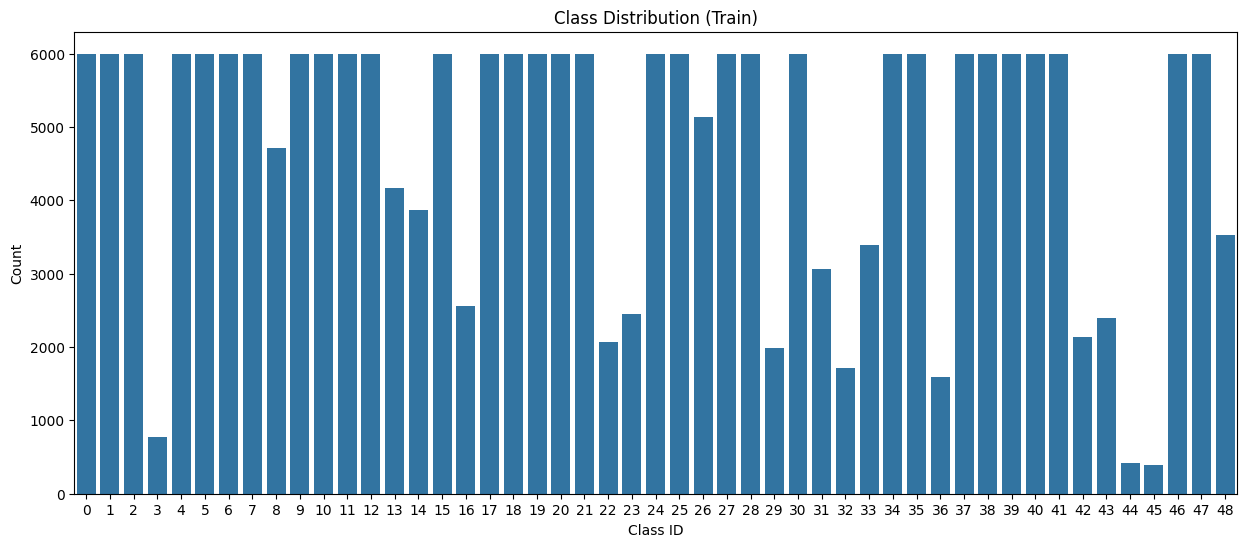

/tmp/ipython-input-3715495844.py:36: UserWarning: Glyph 12402 (\N{HIRAGANA LETTER HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3715495844.py:36: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3715495844.py:36: UserWarning: Glyph 12363 (\N{HIRAGANA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3715495844.py:36: UserWarning: Glyph 12418 (\N{HIRAGANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3715495844.py:36: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3715495844.py:36: UserWarning: Glyph 12367 (\N{HIRAGANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3715495844.py:36: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

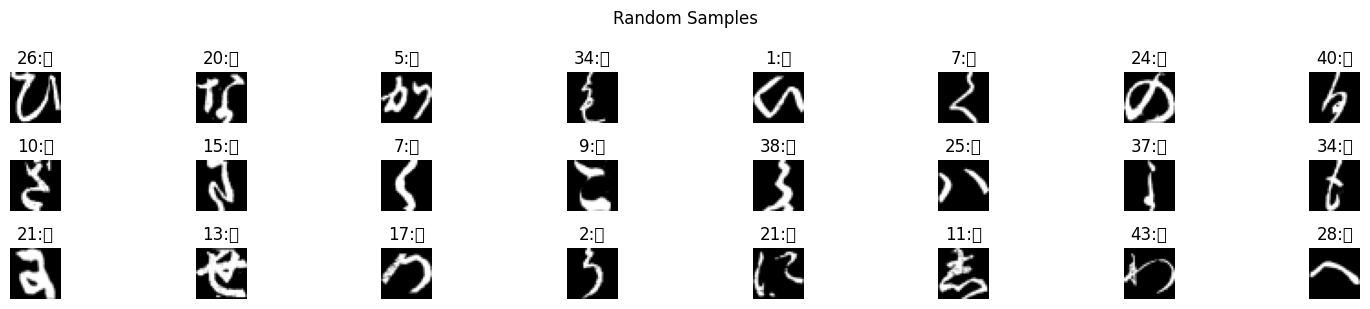

In [3]:
# BLOCK 3: Data Analysis (EDA)
# 1. Calculate Mean and Std for normalization
print("Calculating stats...")
# Normalize temporarily to 0-1 for calc
raw_images = train_dataset_raw.imgs.astype(np.float32) / 255.0
k49_mean = raw_images.mean()
k49_std = raw_images.std()

print(f"Mean: {k49_mean:.4f}")
print(f"Std:  {k49_std:.4f}")

# 2. Visualize Class Distribution
# Good to check for class imbalance
plt.figure(figsize=(15, 6))
sns.countplot(x=train_dataset_raw.labels)
plt.title("Class Distribution (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

# 3. Visualize Random Samples
def show_samples(dataset, num_samples=24, cols=8):
    plt.figure(figsize=(15, 4))
    indices = np.random.randint(0, len(dataset), num_samples)

    for i, idx in enumerate(indices):
        img, label_idx = dataset[idx]
        char = label_map[label_idx]

        plt.subplot(num_samples // cols + 1, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{label_idx}:{char}")
        plt.axis('off')

    plt.suptitle(f"Random Samples")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset_raw)

In [4]:
# BLOCK 4: Data Processing Pipeline
# 1. Define Transforms
# Using calculated mean/std to normalize inputs
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10), # Simple augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=(k49_mean,), std=(k49_std,))
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(k49_mean,), std=(k49_std,))
])

# 2. Dataset Wrapper for PyTorch
class K49Dataset(Dataset):
    def __init__(self, imgs, labels, transform=None):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, int(label)

# 3. Split Training Data into Train (80%) and Validation (20%)
full_train_imgs = train_dataset_raw.imgs
full_train_labels = train_dataset_raw.labels

# Use indices to split
indices = np.arange(len(full_train_imgs))
np.random.shuffle(indices)
split = int(0.8 * len(full_train_imgs))
train_idx, val_idx = indices[:split], indices[split:]

# Create final datasets
train_ds = K49Dataset(full_train_imgs[train_idx], full_train_labels[train_idx], transform=train_transform)
val_ds = K49Dataset(full_train_imgs[val_idx], full_train_labels[val_idx], transform=val_test_transform)
test_ds = K49Dataset(test_dataset_raw.imgs, test_dataset_raw.labels, transform=val_test_transform)

# 4. Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 2905
Val batches:   727
Test batches:  603


In [5]:
# BLOCK 5: Model Architecture

class SimpleCNN(nn.Module):
    """
    Simple CNN for 28x28 grayscale images.
    Structure: 2 Conv layers -> Flatten -> 2 FC layers
    """
    def __init__(self, num_classes=49):
        super(SimpleCNN, self).__init__()

        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Fully Connected Block
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128), # 28/2/2 = 7
            nn.ReLU(),
            nn.Dropout(0.5), # Prevent overfitting
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = SimpleCNN(num_classes=49).to(device)
print(model)

SimpleCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=49, bias=True)
  )
)


In [8]:
# BLOCK 6: Training Loop

EPOCHS = 15
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Store metrics for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for training
    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100. * val_correct / val_total

    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}% | Val Loss={val_loss:.4f}")

print("Done!")

Training for 15 epochs...


Epoch 1: Train Acc=85.61% | Val Acc=94.16% | Val Loss=0.2200


Epoch 2: Train Acc=86.91% | Val Acc=94.57% | Val Loss=0.1996


Epoch 3: Train Acc=87.98% | Val Acc=94.89% | Val Loss=0.1926


Epoch 4: Train Acc=88.53% | Val Acc=95.07% | Val Loss=0.1808


...

Epoch 11: Train Acc=90.93% | Val Acc=95.83% | Val Loss=0.1617


Epoch 12: Train Acc=91.19% | Val Acc=96.03% | Val Loss=0.1517


Epoch 13: Train Acc=91.34% | Val Acc=95.97% | Val Loss=0.1514


Epoch 14: Train Acc=91.52% | Val Acc=95.94% | Val Loss=0.1591


Epoch 15: Train Acc=91.60% | Val Acc=96.10% | Val Loss=0.1505
Done!


Running evaluation on Test Set...

Classification Report:
              precision    recall  f1-score   support

           あ       0.92      0.96      0.94      1000
           い       0.98      0.96      0.97      1000
           う       0.92      0.96      0.94      1000
           え       0.90      0.82      0.86       126
           お       0.94      0.94      0.94      1000
           か       0.91      0.88      0.90      1000
           き       0.93      0.88      0.91      1000
           く       0.89      0.91      0.90      1000
           け       0.84      0.91      0.87       767
           こ       0.90      0.93      0.92      1000
           さ       0.96      0.93      0.94      1000
           し       0.95      0.93      0.94      1000
           す       0.84      0.87      0.85      1000
           せ       0.91      0.76      0.83       678
           そ       0.93      0.86      0.89       629
           た       0.94      0.94      0.94      1000
           ち       0.96

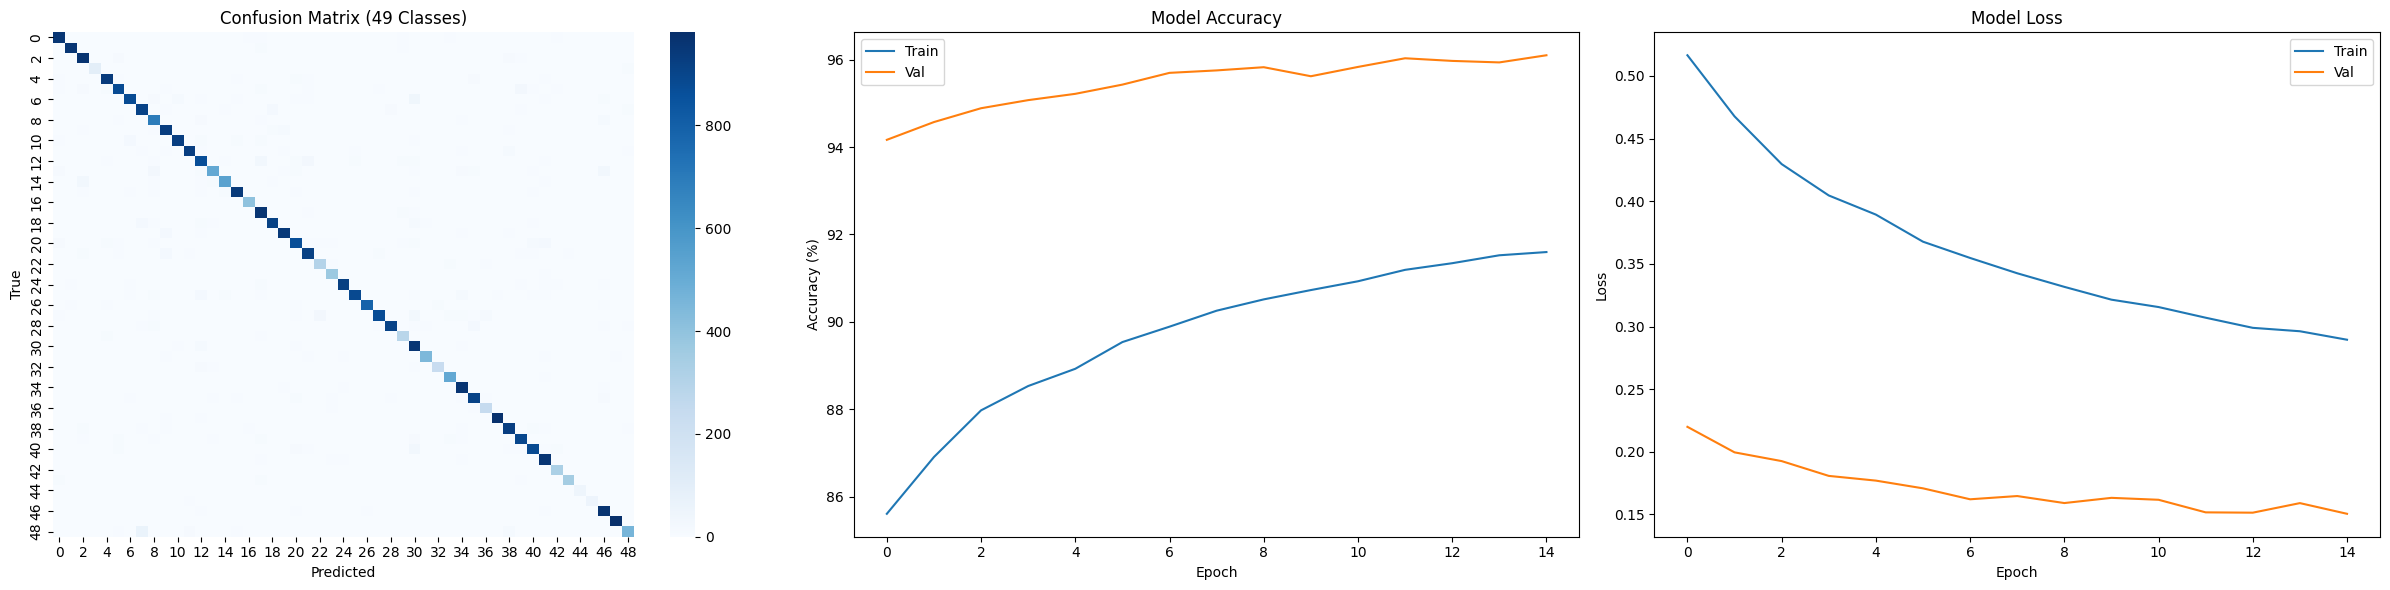

Model saved to: kmnist_model.pth
Tip: Download this file from the file browser if you are on Colab!


In [9]:
# BLOCK 9: Final Evaluation & Model Saving
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Generate Predictions on Test Set
model.eval()
all_preds = []
all_labels = []

print("Running evaluation on Test Set...")

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Classification Report
target_names = [label_map[i] for i in range(len(label_map))]

print("\nClassification Report:")
# Print the full report to see precision/recall for every character
print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

# 3. Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# (A) Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d', ax=axes[0])
axes[0].set_title("Confusion Matrix (49 Classes)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# (B) Accuracy Curve
if 'history' in locals():
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'], label='Val')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()

    # (C) Loss Curve
    axes[2].plot(history['train_loss'], label='Train')
    axes[2].plot(history['val_loss'], label='Val')
    axes[2].set_title('Model Loss')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()

plt.tight_layout()
plt.show()

# 4. Save Model
save_path = "kmnist_model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")
print("Tip: Download this file from the file browser if you are on Colab!")